# House Price Prediction: Data Cleaning, EDA & Regression
**Author:** Shnoda Faik Botros Angly

**Goal:** Predict house sale prices from 79 features (size, quality, location, age, etc.) using the Kaggle *House Prices (Ames, Iowa)* dataset: 1,460 houses in `train.csv` and 1,459 in `test.csv` (no prices).

**Approach:** understand and clean the data, explore what drives price, then compare regression models with cross-validation.

## 1. Load the data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
train = pd.read_csv("train.csv"); test = pd.read_csv("test.csv")
print("train:", train.shape, "| test:", test.shape)
print("Columns only in train:", set(train.columns)-set(test.columns))

train: (1460, 81) | test: (1459, 80)
Columns only in train: {'SalePrice'}


## 2. Data cleaning

**Key catch:** pandas reads the text `NA` and `None` as *missing*. In this dataset, `NA` often means the house **doesn't have** that feature (no pool, no alley, no garage), so it is information, not missing data. Let's see how many missing values pandas reports:

In [2]:
miss = train.isna().sum(); miss = miss[miss>0].sort_values(ascending=False)
print(len(miss), "columns with 'missing' values")
miss.head(12)

19 columns with 'missing' values


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
dtype: int64

In [3]:
# Combine train+test only for consistent cleaning of structural values (no target used)
full = pd.concat([train.drop(columns="SalePrice"), test], keys=["train","test"])
cat_cols = full.select_dtypes(include="object").columns
num_cols = full.select_dtypes(exclude="object").columns.drop("Id")

# 1) Categorical: NaN means "feature not present" -> "None"
full[cat_cols] = full[cat_cols].fillna("None")
# 2) Numeric: area/count features for absent things are 0
for c in ["MasVnrArea","BsmtFinSF1","BsmtFinSF2","BsmtUnfSF","TotalBsmtSF","BsmtFullBath","BsmtHalfBath","GarageCars","GarageArea"]:
    full[c] = full[c].fillna(0)
# 3) No garage: use the year the house was built
full["GarageYrBlt"] = full["GarageYrBlt"].fillna(full["YearBuilt"])
# 4) LotFrontage: median of the same neighborhood
full["LotFrontage"] = full.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))
# 5) MSSubClass is a category code, not a number
full["MSSubClass"] = full["MSSubClass"].astype(str)

print("Remaining missing values:", full.isna().sum().sum())
full.isna().sum().loc[lambda s: s>0]

Remaining missing values: 0


Series([], dtype: int64)

In [4]:
# Feature engineering
full["TotalSF"] = full["TotalBsmtSF"] + full["1stFlrSF"] + full["2ndFlrSF"]
full["HouseAge"] = full["YrSold"] - full["YearBuilt"]
full["TotalBath"] = full["FullBath"] + 0.5*full["HalfBath"] + full["BsmtFullBath"] + 0.5*full["BsmtHalfBath"]
X_all = full.drop(columns="Id")
X = X_all.loc["train"].reset_index(drop=True); X_test = X_all.loc["test"].reset_index(drop=True)
y = train["SalePrice"].reset_index(drop=True)
X.shape, X_test.shape

((1460, 82), (1459, 82))

## 3. Exploratory data analysis

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64
Skewness: 1.88 | after log: 0.12


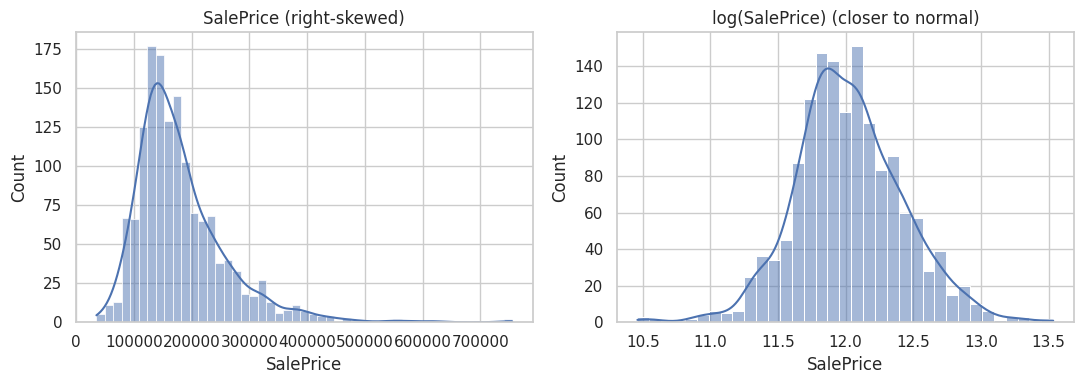

In [5]:
print(y.describe().round(0))
print("Skewness:", round(y.skew(),2), "| after log:", round(np.log1p(y).skew(),2))
fig,ax=plt.subplots(1,2,figsize=(11,4))
sns.histplot(y,kde=True,ax=ax[0]); ax[0].set_title("SalePrice (right-skewed)")
sns.histplot(np.log1p(y),kde=True,ax=ax[1]); ax[1].set_title("log(SalePrice) (closer to normal)")
plt.tight_layout()
plt.show()

OverallQual     0.79
TotalSF         0.78
GrLivArea       0.71
GarageCars      0.64
TotalBath       0.63
GarageArea      0.62
TotalBsmtSF     0.61
1stFlrSF        0.61
FullBath        0.56
TotRmsAbvGrd    0.53
Name: SalePrice, dtype: float64


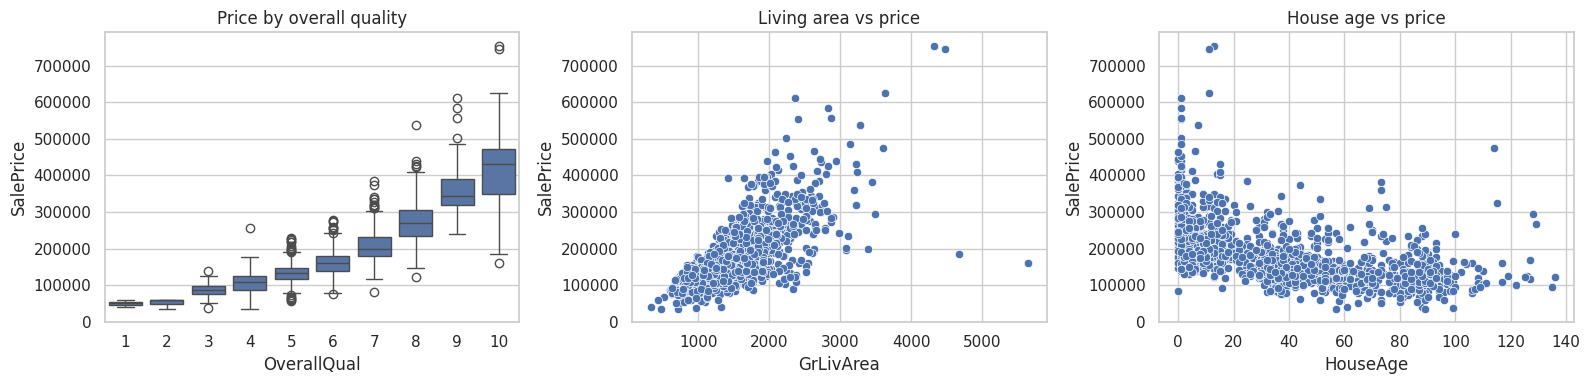

In [6]:
d = X.assign(SalePrice=y)
corr = d.corr(numeric_only=True)["SalePrice"].drop("SalePrice").sort_values(ascending=False)
print(corr.head(10).round(2))
fig,ax=plt.subplots(1,3,figsize=(16,4))
sns.boxplot(x="OverallQual",y="SalePrice",data=d,ax=ax[0]); ax[0].set_title("Price by overall quality")
sns.scatterplot(x="GrLivArea",y="SalePrice",data=d,ax=ax[1]); ax[1].set_title("Living area vs price")
sns.scatterplot(x="HouseAge",y="SalePrice",data=d,ax=ax[2]); ax[2].set_title("House age vs price")
plt.tight_layout()
plt.show()

Neighborhood
StoneBr    278000
NoRidge    301500
NridgHt    315000
Name: SalePrice, dtype: int64
Neighborhood
MeadowV     88000
IDOTRR     103000
BrDale     106000
Name: SalePrice, dtype: int64


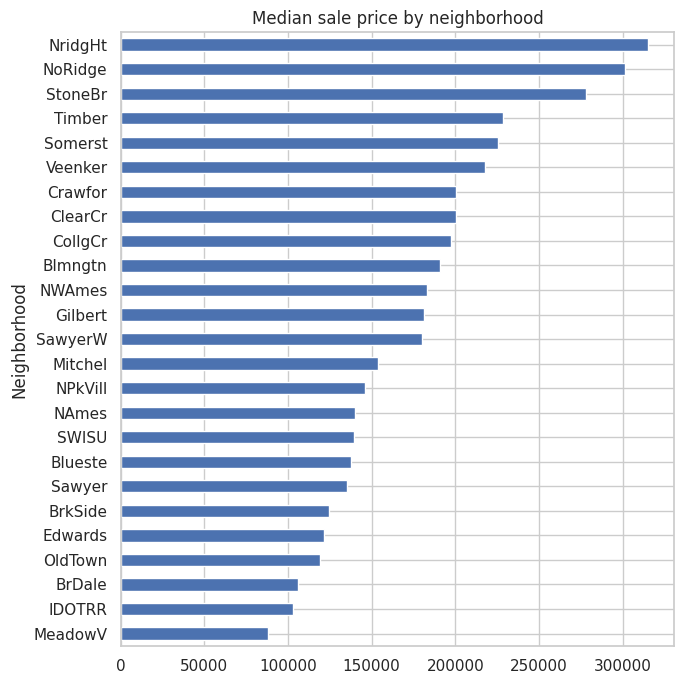

In [7]:
top = d.groupby("Neighborhood")["SalePrice"].median().sort_values()
top.plot.barh(figsize=(7,7),title="Median sale price by neighborhood"); plt.tight_layout()
plt.show()
print(top.tail(3).astype(int)); print(top.head(3).astype(int))

**Outliers:** the scatter plot shows a few very large houses (living area above 4,000 sq ft) that sold for low prices. Those are unusual sales that would mislead a linear model, so I remove them from the training data.

In [8]:
mask = ~((X["GrLivArea"]>4000) & (y<300000))
print("Rows removed:", (~mask).sum())
X, y = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)
X.shape

Rows removed: 2


(1458, 82)

## 4. Modelling
Prices are skewed, so I predict **log(price)**. Errors are then measured as RMSE on the log scale (the metric Kaggle uses for this competition), and R² as an easy-to-read measure. Numeric features are scaled and categoricals one-hot encoded inside a pipeline, so preprocessing is learned only from the training folds.

In [9]:
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

num = X.select_dtypes(exclude="object").columns; cat = X.select_dtypes(include="object").columns
pre = ColumnTransformer([("n",StandardScaler(),num),("c",OneHotEncoder(handle_unknown="ignore"),cat)])
ylog = np.log1p(y)
models = {"Ridge Regression": make_pipeline(pre, Ridge(alpha=10)),
          "Random Forest":    make_pipeline(pre, RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)),
          "Gradient Boosting":make_pipeline(pre, GradientBoostingRegressor(n_estimators=400,learning_rate=0.05,max_depth=3,subsample=0.8,random_state=42))}
kf = KFold(5, shuffle=True, random_state=42)
rows=[]
for n,m in models.items():
    r = cross_validate(m,X,ylog,cv=kf,scoring=("neg_root_mean_squared_error","r2"))
    rows.append((n, round(-r["test_neg_root_mean_squared_error"].mean(),4), round(r["test_r2"].mean(),3)))
results = pd.DataFrame(rows,columns=["model","CV RMSE (log price)","CV R2"]).sort_values("CV RMSE (log price)")
results

               model  CV RMSE (log price)  CV R2
0   Ridge Regression               0.1144  0.918
2  Gradient Boosting               0.1195  0.910
1      Random Forest               0.1362  0.883

Best model: Ridge Regression
Hold-out R2: 0.927
Mean absolute error: $ 14327 | median price: $ 167050


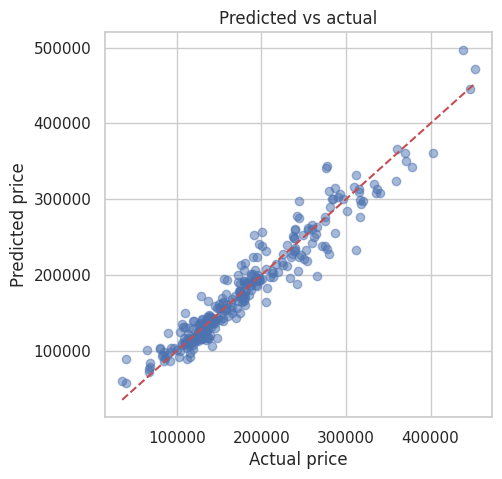

In [10]:
# Hold-out check with the best model, reported in real dollars
best_name = results.iloc[0]["model"]; best = models[best_name]
Xtr,Xva,ytr,yva = train_test_split(X,ylog,test_size=0.2,random_state=42)
best.fit(Xtr,ytr); pred = np.expm1(best.predict(Xva)); actual = np.expm1(yva)
mae = np.mean(np.abs(pred-actual))
print("Best model:", best_name)
print("Hold-out R2:", round(r2_score(actual,pred),3))
print("Mean absolute error: $", int(mae), "| median price: $", int(actual.median()))
plt.figure(figsize=(5,5)); plt.scatter(actual,pred,alpha=.5); lim=[actual.min(),actual.max()]
plt.plot(lim,lim,"r--"); plt.xlabel("Actual price"); plt.ylabel("Predicted price"); plt.title("Predicted vs actual")
plt.show()

In [11]:
# Final model on all training data -> predictions for test.csv (actual prices are hidden, so these cannot be scored here)
best.fit(X, ylog)
sub = pd.DataFrame({"Id": test["Id"], "SalePrice": np.expm1(best.predict(X_test))})
sub.to_csv("submission.csv", index=False)
sub.head()

     Id      SalePrice
0  1461  116404.639532
1  1462  153304.463919
2  1463  179893.591802
3  1464  200050.051071
4  1465  193121.826846

## 5. Conclusions
Write this part yourself after reading the results above: what drives price most (quality, living area, neighborhood?), which model won and by how much, and the limits (one city, sales from 2006-2010, no scoring on test.csv here).